In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
import pandas as pd

In [2]:
# Use f_ext in units of Phi0 by default: phase shift = 2*pi*f_ext.
USE_FLUX_QUANTA = True

phi = np.linspace(-6*np.pi, 6*np.pi, 2500)
flux_values = np.round(np.arange(0.0, 0.51, 0.1), 1)

In [3]:

def phase_shift(f_ext):
    """Return the cosine phase shift for the chosen convention."""
    return 2*np.pi*f_ext if USE_FLUX_QUANTA else f_ext


def V_fluxonium(phi, EL, EJ, f_ext):
    """Fluxonium potential V(phi)/h in GHz."""
    return 0.5*EL*phi**2 - EJ*np.cos(phi + phase_shift(f_ext))


def V_inductive(phi, EL):
    """Inductive-only potential (1/2 EL phi^2)/h in GHz."""
    return 0.5*EL*phi**2


def shared_ylim_for_sweep(EL, EJ, flux_vals, phi, mode="bottom"):
    """
    Pick one y-limit for every subplot in a flux sweep.

    mode="bottom" clips the high sides of the parabola so the well structure is visible.
    mode="full" shows the entire potential over the whole phase range.
    """
    curves = [V_inductive(phi, EL)]
    curves += [V_fluxonium(phi, EL, EJ, f) for f in flux_vals]
    vals = np.concatenate(curves)
    vmin, vmax = np.min(vals), np.max(vals)

    if mode == "full":
        pad = 0.05*(vmax - vmin)
        return vmin - pad, vmax + pad

    if mode == "bottom":
        # Show enough vertical range to see several wells/barriers near the bottom.
        # You can change this number if you want more or less clipping.
        return vmin - 0.05*EJ, vmin + max(6*EJ, 30.0)

    raise ValueError("mode must be 'bottom' or 'full'")


def plot_potential_sweep(EL, EJ, flux_vals=flux_values, phi=phi, ylim=None, ylim_mode="bottom"):
    """Make the six-panel potential plot requested in parts (a), (b), and (c)."""
    if ylim is None:
        ylim = shared_ylim_for_sweep(EL, EJ, flux_vals, phi, mode=ylim_mode)

    fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
    axes = axes.ravel()

    for ax, f_ext in zip(axes, flux_vals):
        ax.plot(phi/np.pi, V_fluxonium(phi, EL, EJ, f_ext), lw=2, label=r"$V(\varphi)/h$")
        ax.plot(phi/np.pi, V_inductive(phi, EL), "--", lw=1.5, label=r"$\frac{1}{2}E_L\varphi^2/h$")
        ax.set_title(rf"$f_{{ext}}={f_ext:.1f}$")
        ax.set_ylim(*ylim)
        ax.set_xlim(-6, 6)
        ax.set_xlabel(r"$\varphi/\pi$")
        ax.set_ylabel("Energy / h (GHz)")

    axes[0].legend(loc="best", fontsize=9)
    fig.suptitle(rf"Fluxonium potential sweep: $E_L={EL}$ GHz, $E_J={EJ}$ GHz", y=1.02)
    fig.tight_layout()
    plt.show()


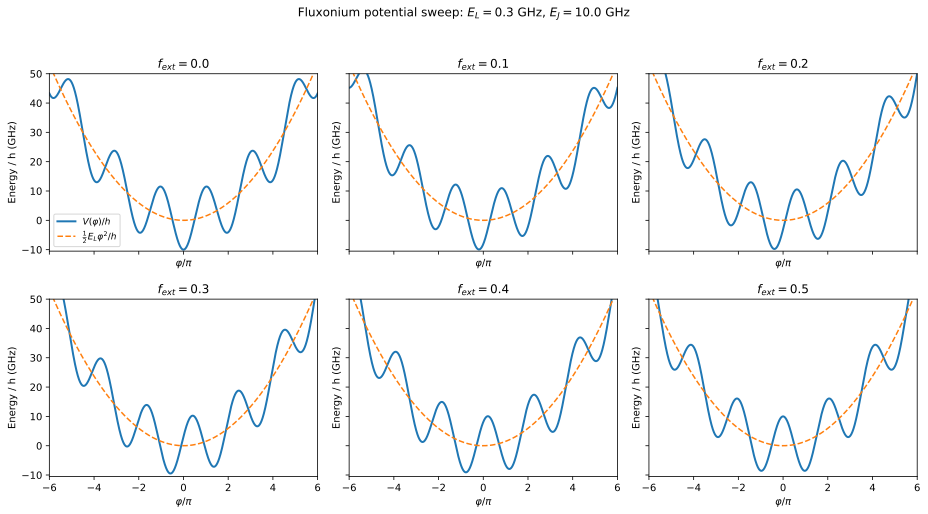

In [4]:

# Part (a)
EL = 0.3
EJ = 10.0

plot_potential_sweep(EL=EL, EJ=EJ, ylim_mode="bottom")


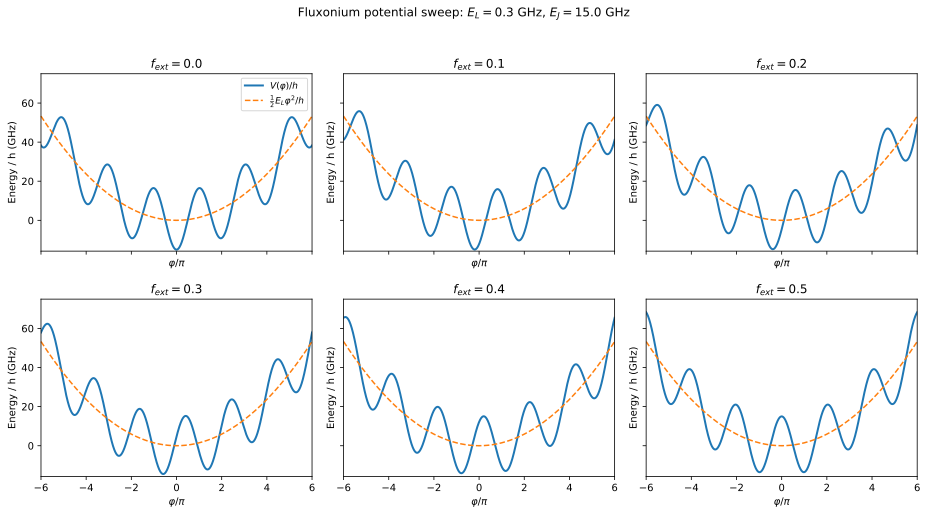

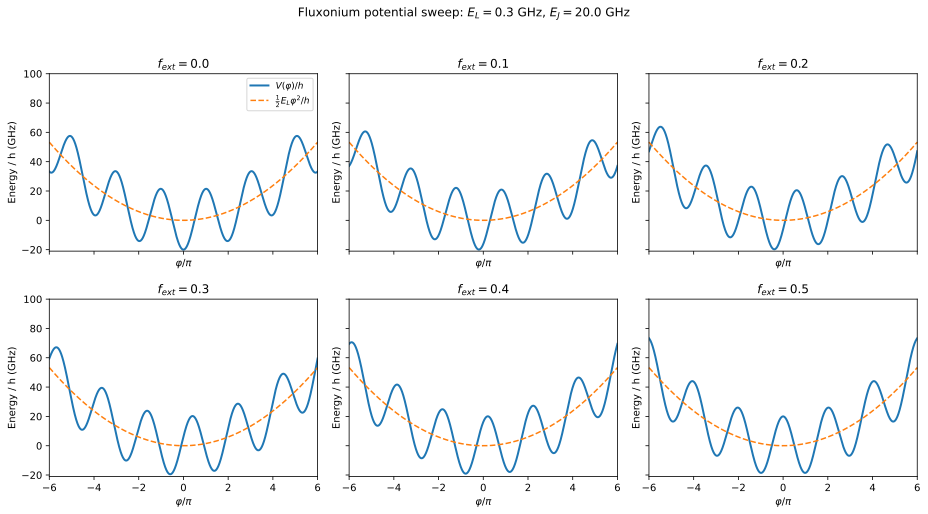

In [5]:

# Part (b)
EL = 0.3

for EJ in [15.0, 20.0]:
    plot_potential_sweep(EL=EL, EJ=EJ, ylim_mode="bottom")


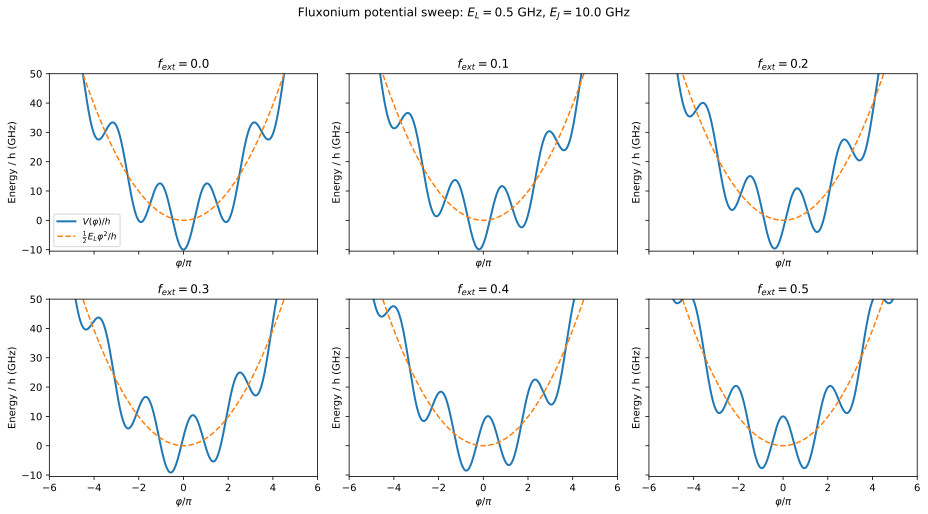

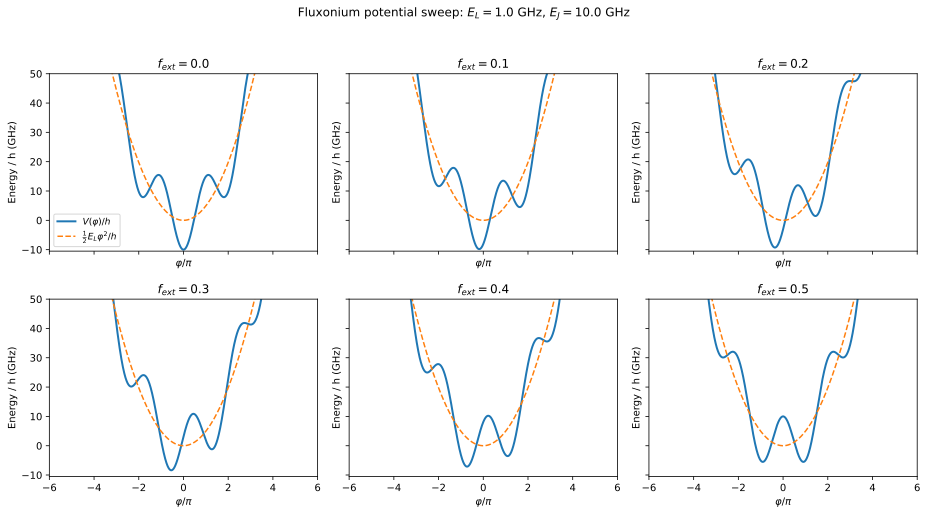

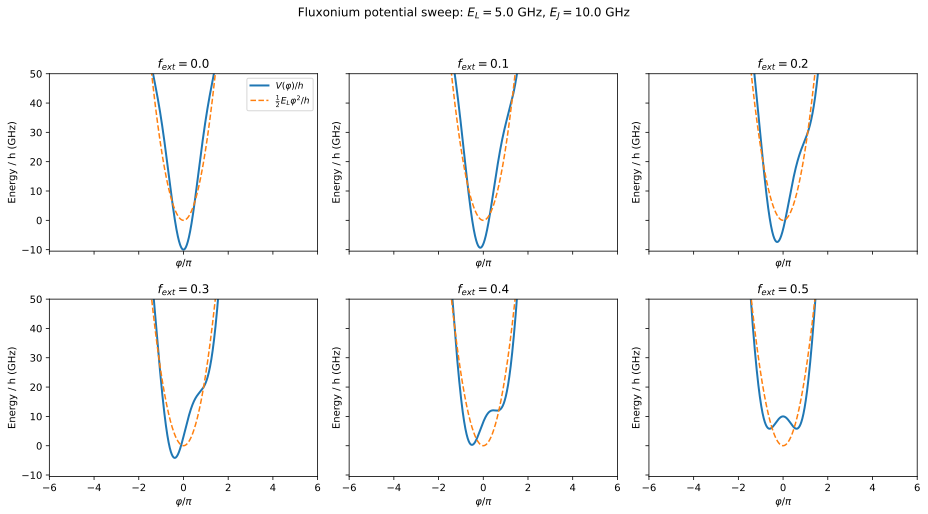

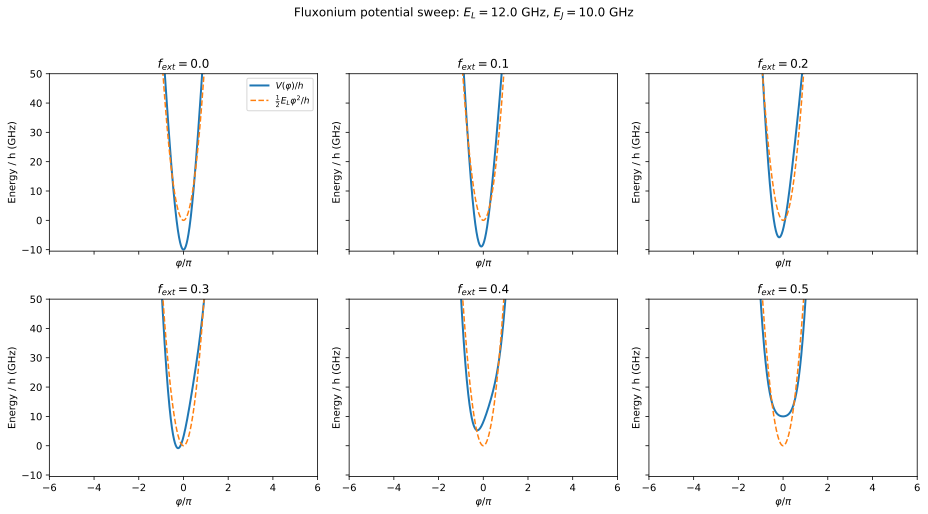

In [6]:

# Part (c)
EJ = 10.0

for EL in [0.5, 1.0, 5.0, 12.0]:
    plot_potential_sweep(EL=EL, EJ=EJ, ylim_mode="bottom")


In [7]:
Grid1d = scq.Grid1d

def make_fluxonium(EC, EL=0.3, EJ=10.0, flux=0.0, cutoff=110, truncated_dim=10):
    """Create a scqubits Fluxonium object."""
    return scq.Fluxonium(
        EJ=EJ,
        EC=EC,
        EL=EL,
        flux=flux,
        cutoff=cutoff,
        truncated_dim=truncated_dim,
    )


def plot_fluxonium_wavefunctions(EC, EL=0.3, EJ=10.0, flux=0.0, cutoff=110,
                                 num_states=5, phi_min=-6*np.pi, phi_max=6*np.pi,
                                 grid_points=1201):
    """
    Diagonalize with scqubits and plot the first few wavefunctions with the potential.
    Wavefunctions are plotted as Re[psi_i(phi)] shifted upward by eigenenergy E_i.
    """
    qubit = make_fluxonium(EC=EC, EL=EL, EJ=EJ, flux=flux, cutoff=cutoff)
    evals, evecs = qubit.eigensys(evals_count=num_states)
    esys = (evals, evecs)

    phi_grid = Grid1d(phi_min, phi_max, grid_points)
    phi_vals = phi_grid.make_linspace()
    V_vals = qubit.potential(phi_vals)

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.plot(phi_vals/np.pi, V_vals, color="black", lw=2, label=r"$V(\varphi)/h$")

    # Choose a visually reasonable energy scaling for the wavefunction amplitudes.
    level_span = max(evals[num_states-1] - evals[0], 1.0)
    wf_scale = 0.25*level_span

    for i in range(num_states):
        wf = qubit.wavefunction(esys=esys, which=i, phi_grid=phi_grid)
        amp = np.real(wf.amplitudes)
        amp_max = np.max(np.abs(amp))
        if amp_max > 0:
            amp = amp / amp_max

        ax.plot(wf.basis_labels/np.pi, evals[i] + wf_scale*amp, lw=1.5,
                label=rf"$\psi_{i}$")
        ax.axhline(evals[i], ls=":", lw=0.8)

    ax.set_xlim(phi_min/np.pi, phi_max/np.pi)
    ax.set_ylim(np.min(V_vals)-0.5, evals[num_states-1] + 2.0*wf_scale)
    ax.set_xlabel(r"$\varphi/\pi$")
    ax.set_ylabel("Energy / h (GHz)")
    ax.set_title(rf"Fluxonium wavefunctions: $E_C={EC}$, $E_L={EL}$, $E_J={EJ}$ GHz, $f_{{ext}}={flux}$")
    ax.legend(loc="best", fontsize=8, ncol=2)
    fig.tight_layout()
    plt.show()

    return evals


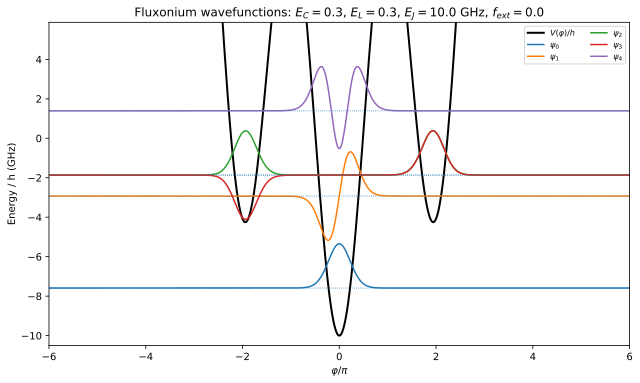

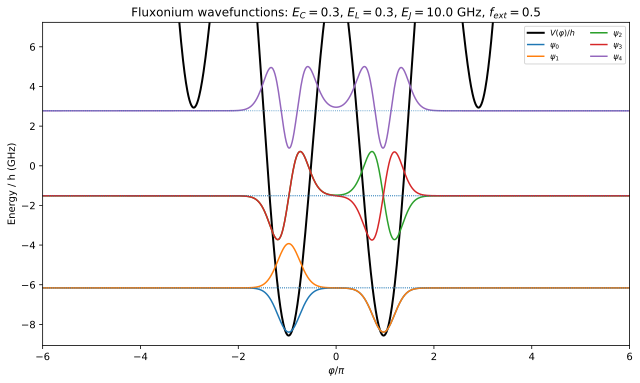

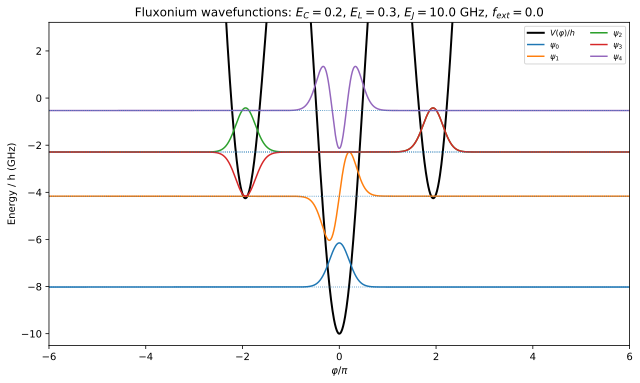

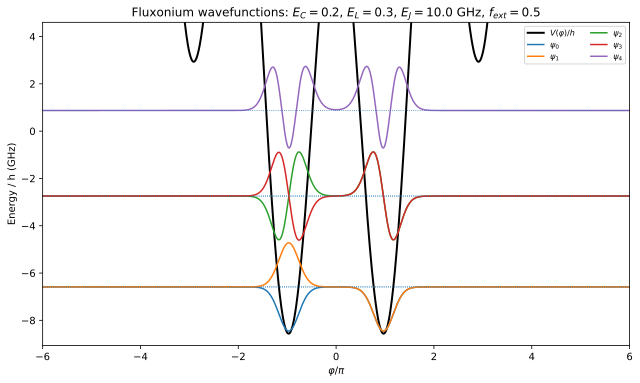

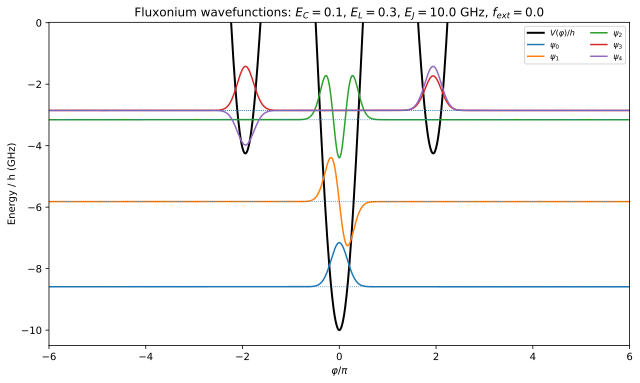

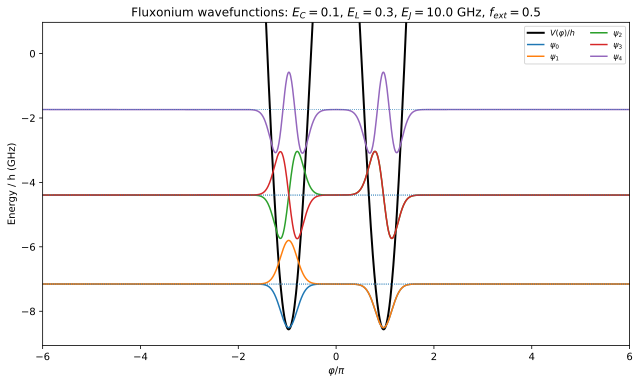

,EC (GHz),EL (GHz),EJ (GHz),f_ext,E0 (GHz),E1 (GHz),E2 (GHz),E3 (GHz),E4 (GHz)
0,0.3,0.3,10.0,0.0,-7.589100,-2.928156,-1.864348,-1.864348,1.389471
1,0.3,0.3,10.0,0.5,-6.157752,-6.157745,-1.513167,-1.512786,2.771448
2,0.2,0.3,10.0,0.0,-8.019965,-4.164927,-2.290162,-2.290162,-0.530308
3,0.2,0.3,10.0,0.5,-6.587371,-6.587371,-2.744274,-2.744260,0.871967
4,0.1,0.3,10.0,0.0,-8.589417,-5.819462,-3.155108,-2.853512,-2.853512
5,0.1,0.3,10.0,0.5,-7.155317,-7.155317,-4.392854,-4.392854,-1.738296


In [8]:

# Part (d)
EC_values = [0.3, 0.2, 0.1]
EL = 0.3
EJ = 10.0
flux_points = [0.0, 0.5]

energy_rows = []
for EC in EC_values:
    for f_ext in flux_points:
        evals = plot_fluxonium_wavefunctions(EC=EC, EL=EL, EJ=EJ, flux=f_ext, cutoff=110, num_states=5)
        row = {"EC (GHz)": EC, "EL (GHz)": EL, "EJ (GHz)": EJ, "f_ext": f_ext}
        for i, energy in enumerate(evals):
            row[f"E{i} (GHz)"] = energy
        energy_rows.append(row)

pd.DataFrame(energy_rows)
